# Standalone conduction and repolarization preprocessing branch

**Purpose.** Convert explicit R anchors and aligned P/QRS/T landmarks
into beatwise conduction/repolarization intervals, QT-correction
alternatives, first differences, causal 30-beat variability summaries,
five-beat information windows, and nine-beat QT context.

### Core beat measurements

\[
PR=P_{onset}\rightarrow QRS_{onset},\quad
QRS=QRS_{onset}\rightarrow QRS_{offset},\quad
QT=QRS_{onset}\rightarrow T_{offset},\quad
JT=QRS_{offset}\rightarrow T_{offset}
\]

\[
QTc_B=\frac{QT}{\sqrt{RR_s}},\qquad
QTc_F=\frac{QT}{\sqrt[3]{RR_s}},\qquad
QTc_{Framingham}=QT+154(1-RR_s)
\]

The branch is information-only: it does not diagnose conduction disease,
apply clinical thresholds, label abnormality, or predict seizures.

## 1. Reproducible environment and data selection

This notebook is **independent of the other notebooks**. It locates the
project, imports the installed/tested branch package, selects one ECG
channel explicitly, creates its own output directory, and records the
runtime versions. The executable example uses MIT–BIH record 100,
channel `MLII`, starting at 0 s for 120 s.

Change only the configuration cell below to use another WFDB record.
For EDF data, use `ecg_cascade.edf.load_ecg_segment` after explicitly
inspecting and choosing the ECG channel.

#### Code walkthrough — imports, project discovery, and frozen run configuration

        **Why this cell exists.** Every later result depends on using the intended package, dataset, lead, units, and output folder.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Imports | Loads hashing, tables, numerical methods, plotting, NeuroKit, WFDB, and notebook display helpers. | The notebook needs both computation and visible audit evidence. |
| 2 | Project discovery | Searches the current directory and its parents for `pyproject.toml` and `src/ecg_cascade`, then places `src` on `sys.path`. | The same notebook must run from the repository root or its own folder without importing an unrelated installed copy. |
| 3 | Output contract | Creates one branch-specific directory under `outputs/standalone_notebooks`. | CSV, JSON, and manifests remain separate and reproducible. |
| 4 | Input configuration | Freezes record 100, lead MLII, start, duration, and patient identifier; the header assertion fails early if data are missing. | A clinical reader must know exactly which signal produced the figures. |
| 5 | Display configuration | Applies a consistent plot style and wide table display. | Successful runs should be readable without hidden columns or default styling ambiguity. |
| 6 | Version printout | Prints Python and dependency versions plus resolved paths. | A future rerun can distinguish data or code changes from environment changes. |

        **Evidence that the cell ran correctly**

        - A compact version block is printed with Python, NumPy, pandas, SciPy, NeuroKit2, and WFDB versions.
- `Project` resolves to the repository's `feature_extraction` folder and `Output` resolves to this branch's folder.
- No import, missing-file, or path assertion error appears.

        **If that evidence is absent, investigate**

        - A wrong working directory or a missing `feature_extraction/pyproject.toml`.
- The MIT–BIH dataset path or the requested lead name.
- A notebook kernel that is not using the project virtual environment.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import neurokit2 as nk
import wfdb
from IPython.display import Code, Markdown, display

# Locate feature_extraction regardless of whether execution starts from
# the repository root, feature_extraction, or the notebook directory.
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT = next(
    path for path in search_roots
    if (path / "pyproject.toml").is_file()
    and (path / "src" / "ecg_cascade").is_dir()
)
ROOT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTPUT_DIR = PROJECT / "outputs" / "standalone_notebooks" / "conduction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMO_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "100"
)
assert DEMO_RECORD.with_suffix(".hea").is_file(), DEMO_RECORD

RECORD_PATH = DEMO_RECORD       # WFDB path without extension
CHANNEL = "MLII"                # explicit lead choice
START_S = 0.0
DURATION_S = 120.0
PATIENT_ID = "mitdb_100"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#304955",
    "text.color": "#203845",
})
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("NumPy:", np.__version__, "Pandas:", pd.__version__, "SciPy:", scipy.__version__)
print("NeuroKit2:", nk.__version__, "WFDB:", wfdb.__version__)
print("Project:", PROJECT)
print("Output:", OUTPUT_DIR)

Python: 3.12.10
NumPy: 2.4.2 Pandas: 2.3.3 SciPy: 1.17.0
NeuroKit2: 0.2.13 WFDB: 4.3.1
Project: C:\Users\Salam\Documents\ECGdetector\feature_extraction
Output: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\conduction


#### Code walkthrough — load, validate, summarize, and preview the input ECG

        **Why this cell exists.** Algorithm outputs are interpretable only after the waveform, sampling rate, time coordinates, units, and finite-sample checks are visible.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Loader import | Imports the project's WFDB segment loader. | This centralizes channel lookup and physical-unit conversion instead of duplicating raw WFDB calls. |
| 2 | Segment read | Loads the configured lead and time range, then extracts samples and sampling frequency. | Every sample index used later must map to a physical time. |
| 3 | Time axis | Builds an absolute time vector from the segment start and sample rate. | Plots and event tables then share the same coordinate system. |
| 4 | Assertions | Requires one-dimensional, finite data and at least three seconds of signal. | Downstream filters and interval calculations should fail visibly rather than accept malformed input. |
| 5 | Summary | Prints source, lead, sampling rate, sample count, time span, and amplitude range. | This is the run's input provenance and first unit sanity check. |
| 6 | Preview figure | Plots the first 12 seconds of the unmodified physical ECG. | A reviewer can see polarity, gain, baseline, and recognizable beats before any branch operates. |

        **Evidence that the cell ran correctly**

        - The summary reports 360 Hz, the requested duration, finite amplitude limits, and channel MLII.
- The figure shows a continuous ECG trace with no blank panel or clipped time axis.
- The x-axis is seconds and the y-axis explicitly says physical WFDB units.

        **If that evidence is absent, investigate**

        - Lead selection, start/duration bounds, or a corrupt/missing WFDB pair.
- NaN/Inf samples, an unexpectedly flat trace, or an amplitude scale inconsistent with the header.
- A wrong sampling rate, because every millisecond conversion below depends on it.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

{'source': 'C:\\Users\\Salam\\Documents\\ECGdetector\\Datasets\\mit-bih-arrhythmia-database-1.0\\mit-bih-arrhythmia-database-1.0.0\\100', 'channel': 'MLII', 'sampling_rate_hz': 360.0, 'samples': 43200, 'start_s': 0.0, 'duration_s': 120.0, 'minimum': -0.695, 'maximum': 1.125}


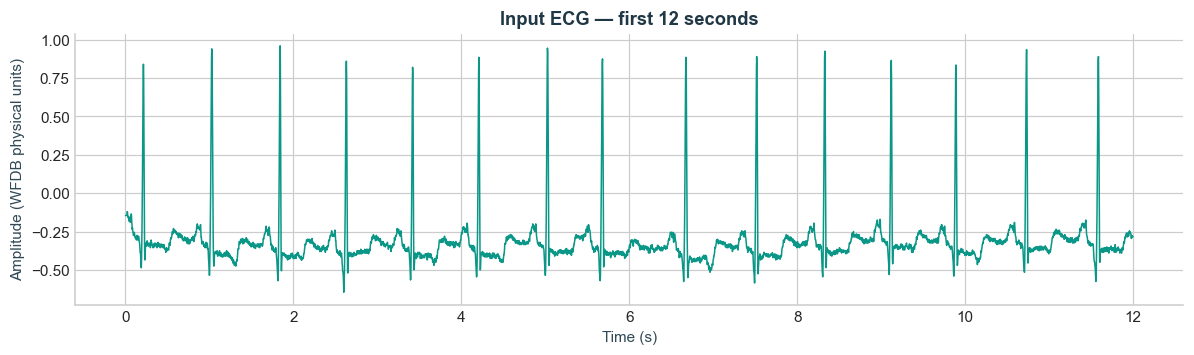

In [2]:
from ecg_cascade.wfdb_io import load_wfdb_segment

segment = load_wfdb_segment(
    RECORD_PATH,
    channel=CHANNEL,
    start_s=START_S,
    duration_s=DURATION_S,
)
ecg = segment.samples
fs = float(segment.sampling_rate_hz)
time_s = segment.start_s + np.arange(ecg.size) / fs

assert ecg.ndim == 1
assert np.all(np.isfinite(ecg))
assert ecg.size >= int(3 * fs)
print({
    "source": segment.record_path,
    "channel": segment.channel_name,
    "sampling_rate_hz": fs,
    "samples": int(ecg.size),
    "start_s": segment.start_s,
    "duration_s": segment.duration_s,
    "minimum": float(ecg.min()),
    "maximum": float(ecg.max()),
})

preview = time_s < time_s[0] + 12
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(time_s[preview], ecg[preview], color="#0b9787", lw=1.0)
ax.set(title="Input ECG — first 12 seconds", xlabel="Time (s)", ylabel="Amplitude (WFDB physical units)")
plt.show()

### Reproducibility rules used throughout

- No missing-sample imputation is performed.
- The selected channel and physical-unit scale are shown explicitly.
- Detector disagreement is context, not ground truth or artifact.
- All rolling windows are trailing/causal where the implementation says so.
- No notebook cell trains a seizure classifier or produces a clinical label.
- Tables are exported separately so intermediate measurements remain auditable.

## 2. Detect R anchors and delineate P–QRS–T landmarks

#### Code walkthrough — create named ventricular anchors and P/QRS/T landmarks

        **Why this cell exists.** Conduction intervals are differences between boundaries, so anchor and delineator provenance must precede every number.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Detector run | Builds the NeuroKit–Zhai cascade and selects the named NeuroKit lane for the demonstration. | R anchors define beat identity and RR context. |
| 2 | Prominence delineation | Finds P, QRS, and T landmarks on those anchors. | PR/QRS/QT/JT require explicit endpoints. |
| 3 | Feature table | Retains one row per anchor with values and completeness/order flags. | Missing landmarks remain attached to their beat. |
| 4 | Summary preview | Shows aggregate availability and the first rows. | Coverage and schema can be checked before interval arithmetic. |

        **Evidence that the cell ran correctly**

        - The summary reports many anchors and complete QRS/PQRST rows.
- The preview contains sample indices, measurements, and validity flags.

        **If that evidence is absent, investigate**

        - A poor anchor track, especially on atrial or broad-QRS deflections.
- Missing P onset/T offset coverage.
- Treating the automatic delineator as manual interval truth.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [3]:
from ecg_cascade import NeuroKitZhaiConfig, run_neurokit_zhai_array
from ecg_cascade.prominence_morphology import extract_prominence_morphology

cascade = run_neurokit_zhai_array(
    ecg, fs, config=NeuroKitZhaiConfig(compute_inverted_context=False)
)
track = cascade.selected.neurokit
prominence = extract_prominence_morphology(
    ecg, track.detector.peak_samples, fs,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
    segment_start_s=segment.start_s,
)
pqrst = prominence.features
display(pd.Series(prominence.summary(), name="delineation summary"))
display(pqrst.head(4))

anchor_track                                                               neurokit
beat_count                                                                      148
complete_qrs_count                                                              148
complete_qs_peak_count                                                          148
q_s_peak_order_pass_count                                                       148
complete_pqrst_count                                                            147
physiological_order_pass_count                                                  147
parameters                        {'method': 'emrich2024_prominence_via_neurokit...
seizure_probability_produced                                                  False
artifact_label_produced                                                       False
Name: delineation summary, dtype: object

,beat_index,anchor_track,patient_id,lead_name,r_peak_sample_in_segment,r_peak_time_s,p_onset_sample_in_segment,p_peak_sample_in_segment,p_offset_sample_in_segment,qrs_onset_sample_in_segment,qrs_offset_sample_in_segment,t_onset_sample_in_segment,t_peak_sample_in_segment,t_offset_sample_in_segment,q_peak_sample_in_segment,s_peak_sample_in_segment,landmark_availability_fraction,complete_p,complete_qrs,complete_t,complete_pqrst,physiological_order_valid,complete_qs_peaks,q_s_peak_order_valid,p_duration_ms,pr_interval_ms,qrs_duration_ms,st_interval_ms,qt_interval_ms,r_to_t_peak_ms,baseline_amplitude,p_peak_amplitude_from_baseline,r_anchor_amplitude_from_baseline,t_peak_amplitude_from_baseline,qrs_peak_to_peak_amplitude,qrs_signed_area,qrs_polarity,seizure_probability_produced,artifact_label_produced
0,0,neurokit,mitdb_100,MLII,77,0.213889,<NA>,8,26,65,87,118,142,173,65,87,0.875,False,True,True,False,False,True,True,NaN,NaN,61.111111,86.111111,300.000000,180.555556,-0.3025,0.1825,1.1425,-0.0275,1.325,0.016444,positive,False,False
1,1,neurokit,mitdb_100,MLII,370,1.027778,292,310,328,358,382,435,471,501,358,382,1.000,True,True,True,True,True,True,True,100.0,183.333333,66.666667,147.222222,397.222222,280.555556,-0.3475,0.1325,1.2875,-0.1075,1.475,0.023521,positive,False,False
2,2,neurokit,mitdb_100,MLII,662,1.838889,586,604,622,651,673,738,756,782,651,673,1.000,True,True,True,True,True,True,True,100.0,180.555556,61.111111,180.555556,363.888889,261.111111,-0.3800,0.1400,1.2650,-0.0550,1.530,0.019194,positive,False,False
3,3,neurokit,mitdb_100,MLII,946,2.627778,866,884,902,935,957,1030,1063,1087,935,957,1.000,True,True,True,True,True,True,True,100.0,191.666667,61.111111,202.777778,422.222222,325.000000,-0.4200,0.1750,1.2300,0.1500,1.505,0.019736,positive,False,False


The prominence delineator is an upstream measurement method, not manual
reference truth. Missing landmarks remain missing. `complete_pqrst` and
`physiological_order_valid` make per-beat availability explicit.

#### Code walkthrough — show exactly which landmarks feed the interval equations

        **Why this cell exists.** A non-coder can understand PR, QRS, QT, and JT only if their endpoints are visible on one beat.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Valid-beat selection | Chooses a complete, physiologically ordered PQRST row. | No hidden interpolation fills absent endpoints. |
| 2 | Named coordinates | Builds an integer sample dictionary for all nine landmarks. | The plot and source table share exact indices. |
| 3 | Context crop | Displays the waveform from just before P onset to just after T offset. | The whole conduction/repolarization cycle is visible. |
| 4 | Markers/labels | Places and names every landmark at its raw amplitude. | The screenshot is an anatomy key for later formulas. |

        **Evidence that the cell ran correctly**

        - Nine labels occur in physiological left-to-right order on one ECG cycle.

        **If that evidence is absent, investigate**

        - An edge beat or invalid landmark order.
- Labels placed on a filtered trace while sample indices refer to raw ECG.
- Overlapping annotations that obscure P or T endpoints.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

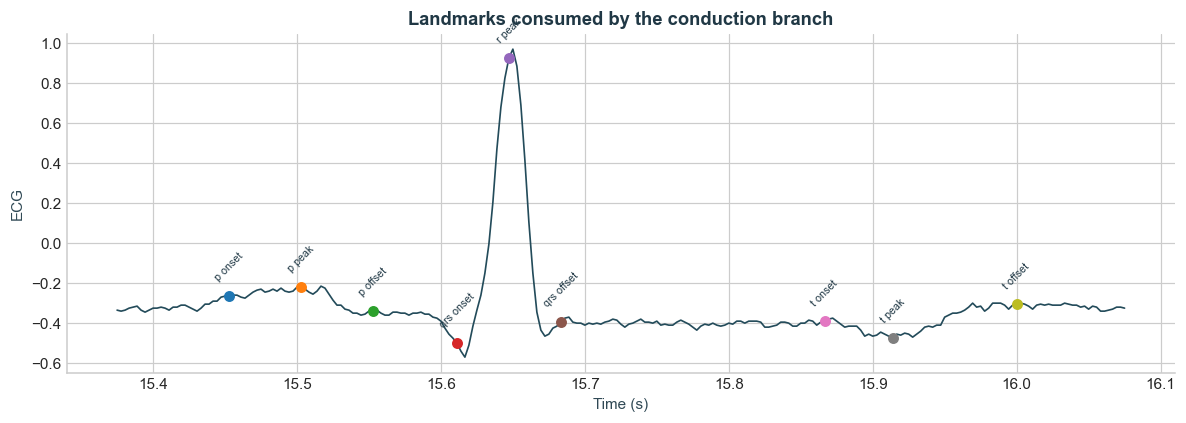

In [4]:
valid = np.flatnonzero((pqrst["complete_pqrst"] & pqrst["physiological_order_valid"]).to_numpy(bool))
beat_index = int(valid[min(18, len(valid) - 1)])
beat = pqrst.iloc[beat_index]
columns = [
    "p_onset_sample_in_segment", "p_peak_sample_in_segment", "p_offset_sample_in_segment",
    "qrs_onset_sample_in_segment", "r_peak_sample_in_segment", "qrs_offset_sample_in_segment",
    "t_onset_sample_in_segment", "t_peak_sample_in_segment", "t_offset_sample_in_segment",
]
landmarks = {name: int(beat[name]) for name in columns}
first = max(0, landmarks["p_onset_sample_in_segment"] - int(.08 * fs))
last = min(ecg.size, landmarks["t_offset_sample_in_segment"] + int(.08 * fs))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.arange(first, last) / fs, ecg[first:last], color="#234b5a", lw=1.1)
for name, sample in landmarks.items():
    short = name.replace("_sample_in_segment", "").replace("_", " ")
    ax.scatter(sample / fs, ecg[sample], s=38, zorder=3)
    ax.annotate(short, (sample / fs, ecg[sample]), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=7, rotation=45)
ax.set(title="Landmarks consumed by the conduction branch", xlabel="Time (s)", ylabel="ECG")
plt.show()

## 3. Run frozen beatwise timing equations and 30-beat summaries

#### Code walkthrough — calculate frozen beatwise intervals, QTc alternatives, and 30-beat summaries

        **Why this cell exists.** The branch needs both interpretable current-beat values and trailing variability, each with explicit missingness.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Timing extractor | Consumes the PQRST table at the known sampling rate with a 30-beat window and 80% minimum valid fraction. | Parameters controlling availability are explicit. |
| 2 | Beat table | Returns RR/HR context, raw intervals, QTc alternatives, differences, and defined flags. | No single QT correction is silently privileged. |
| 3 | Rolling table | Returns causal 30-beat summaries and variability measures. | Longer context is kept separate from beatwise measurements. |
| 4 | Summary/preview | Displays counts and selected columns for the first beats. | Warm-up and missing endpoints are visible. |

        **Evidence that the cell ran correctly**

        - Beat rows equal anchor rows and finite PR/QRS/QT/JT values appear after the first beat where applicable.
- The summary reports nonzero rolling-feature availability.

        **If that evidence is absent, investigate**

        - Sampling-rate or endpoint-unit errors.
- Missing preceding RR for the first beat—this is expected.
- Treating QTc alternatives as diagnoses or interchangeable numbers.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [5]:
from ecg_cascade.conduction_timing import extract_conduction_timing

timing = extract_conduction_timing(
    pqrst, fs,
    variability_window_beats=30,
    minimum_valid_fraction=0.8,
    landmark_method=prominence.parameters["method"],
)
beats = timing.beat_features
rolling30 = timing.rolling_features
display(pd.Series(timing.summary(), name="conduction timing v1 summary"))
display(beats[[
    "beat_index", "r_peak_time_s", "preceding_rr_ms", "instantaneous_heart_rate_bpm",
    "pr_interval_ms", "qrs_duration_ms", "qt_interval_ms", "jt_interval_ms",
    "qtc_bazett_ms", "qtc_fridericia_ms", "qtc_framingham_ms",
    "all_raw_wave_intervals_defined"
]].head(8))

branch_name                                                                conduction
beat_count                                                                        148
rolling_row_count                                                                 148
pr_defined_count                                                                  147
qrs_defined_count                                                                 148
qt_defined_count                                                                  148
parameters                          {'branch_name': 'conduction', 'schema_version'...
diagnostics                         {'interval_level_manual_validation': 'pending'...
seizure_probability_produced                                                    False
clinical_interpretation_produced                                                False
Name: conduction timing v1 summary, dtype: object

,beat_index,r_peak_time_s,preceding_rr_ms,instantaneous_heart_rate_bpm,pr_interval_ms,qrs_duration_ms,qt_interval_ms,jt_interval_ms,qtc_bazett_ms,qtc_fridericia_ms,qtc_framingham_ms,all_raw_wave_intervals_defined
0,0,0.213889,NaN,NaN,NaN,61.111111,300.000000,238.888889,NaN,NaN,NaN,False
1,1,1.027778,813.888889,73.720137,183.333333,66.666667,397.222222,330.555556,440.302323,425.446704,425.883333,True
2,2,1.838889,811.111111,73.972603,180.555556,61.111111,363.888889,302.777778,404.043961,390.189290,392.977778,True
3,3,2.627778,788.888889,76.056338,191.666667,61.111111,422.222222,361.111111,475.371529,456.950483,454.733333,True
4,4,3.419444,791.666667,75.789474,194.444444,58.333333,383.333333,325.000000,430.829473,414.377150,415.416667,True
5,5,4.208333,788.888889,76.056338,161.111111,58.333333,402.777778,344.444444,453.479419,435.906711,435.288889,True
6,6,5.025000,816.666667,73.469388,194.444444,61.111111,288.888889,227.777778,319.674816,309.064575,317.122222,True
7,7,5.677778,652.777778,91.914894,183.333333,61.111111,502.777778,441.666667,622.290819,579.590093,556.250000,True


## 4. Direct equation checks for one complete beat

#### Code walkthrough — independently verify interval and QT-correction equations

        **Why this cell exists.** A direct one-beat calculation catches sign, endpoint, unit, and row-alignment errors that plots may hide.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Complete-row choice | Selects a beat where all raw intervals are defined. | The reference calculation needs every endpoint. |
| 2 | Direct differences | Computes PR, QRS, QT, and JT from sample differences times 1000/fs. | This is the physical definition of each interval. |
| 3 | Stored comparison | Checks every direct result against the branch table. | A swapped endpoint or offset fails immediately. |
| 4 | QTc checks | Uses preceding RR seconds to recompute Bazett and Fridericia values. | The denominator unit and exponent are explicitly tested. |
| 5 | Comparison table | Shows direct and stored values side-by-side. | The PI can verify exact equality visually. |

        **Evidence that the cell ran correctly**

        - The table's direct/stored columns match and the final sentence confirms equation checks passed.

        **If that evidence is absent, investigate**

        - Milliseconds versus seconds in RR.
- Using T peak instead of T offset for QT.
- Row mismatch between landmarks and beat features.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [6]:
check_index = int(np.flatnonzero(beats["all_raw_wave_intervals_defined"].to_numpy(bool))[5])
raw = pqrst.iloc[check_index]
measured = beats.iloc[check_index]
direct = {
    "pr_interval_ms": (float(raw.qrs_onset_sample_in_segment) - float(raw.p_onset_sample_in_segment)) * 1000 / fs,
    "qrs_duration_ms": (float(raw.qrs_offset_sample_in_segment) - float(raw.qrs_onset_sample_in_segment)) * 1000 / fs,
    "qt_interval_ms": (float(raw.t_offset_sample_in_segment) - float(raw.qrs_onset_sample_in_segment)) * 1000 / fs,
    "jt_interval_ms": (float(raw.t_offset_sample_in_segment) - float(raw.qrs_offset_sample_in_segment)) * 1000 / fs,
}
for column, value in direct.items():
    np.testing.assert_allclose(value, float(measured[column]))
rr_s = float(measured.preceding_rr_ms) / 1000.0
np.testing.assert_allclose(float(measured.qtc_bazett_ms), direct["qt_interval_ms"] / np.sqrt(rr_s))
np.testing.assert_allclose(float(measured.qtc_fridericia_ms), direct["qt_interval_ms"] / np.cbrt(rr_s))
display(pd.DataFrame({"direct_calculation": direct, "stored_value": {key: measured[key] for key in direct}}))
print("Beatwise interval and QTc equation checks passed.")

,direct_calculation,stored_value
pr_interval_ms,194.444444,194.444444
qrs_duration_ms,61.111111,61.111111
qt_interval_ms,288.888889,288.888889
jt_interval_ms,227.777778,227.777778


Beatwise interval and QTc equation checks passed.


#### Code walkthrough — plot raw intervals, QTc alternatives, and causal QT variability

        **Why this cell exists.** The figure shows that formula choice and landmark variability materially affect the curves; no correction should be hidden behind a generic `QTc` label.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Raw intervals | Plots PR, QRS, QT, and JT for every beat where defined. | Different endpoints create distinct trajectories and scales. |
| 2 | QTc alternatives | Plots Bazett, Fridericia, and Framingham with separate names. | Rate correction is a modeling choice, not a universal transformation. |
| 3 | Defined-window mask | Keeps only rows where the 30-beat QT summary meets its requirement. | Warm-up/missingness are not plotted as zeros. |
| 4 | Variability curves | Shows QT SD30 and RMSSD30 against time. | The PI sees why endpoint error can inflate variability. |

        **Evidence that the cell ran correctly**

        - Three stacked panels appear; the variability panel begins only after sufficient history.
- QTc curves are similar but not identical.

        **If that evidence is absent, investigate**

        - Huge discontinuities caused by failed T offsets.
- A generic unlabeled QTc column.
- Interpreting automatic QT variability as validated physiology before the manual interval gate passes.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

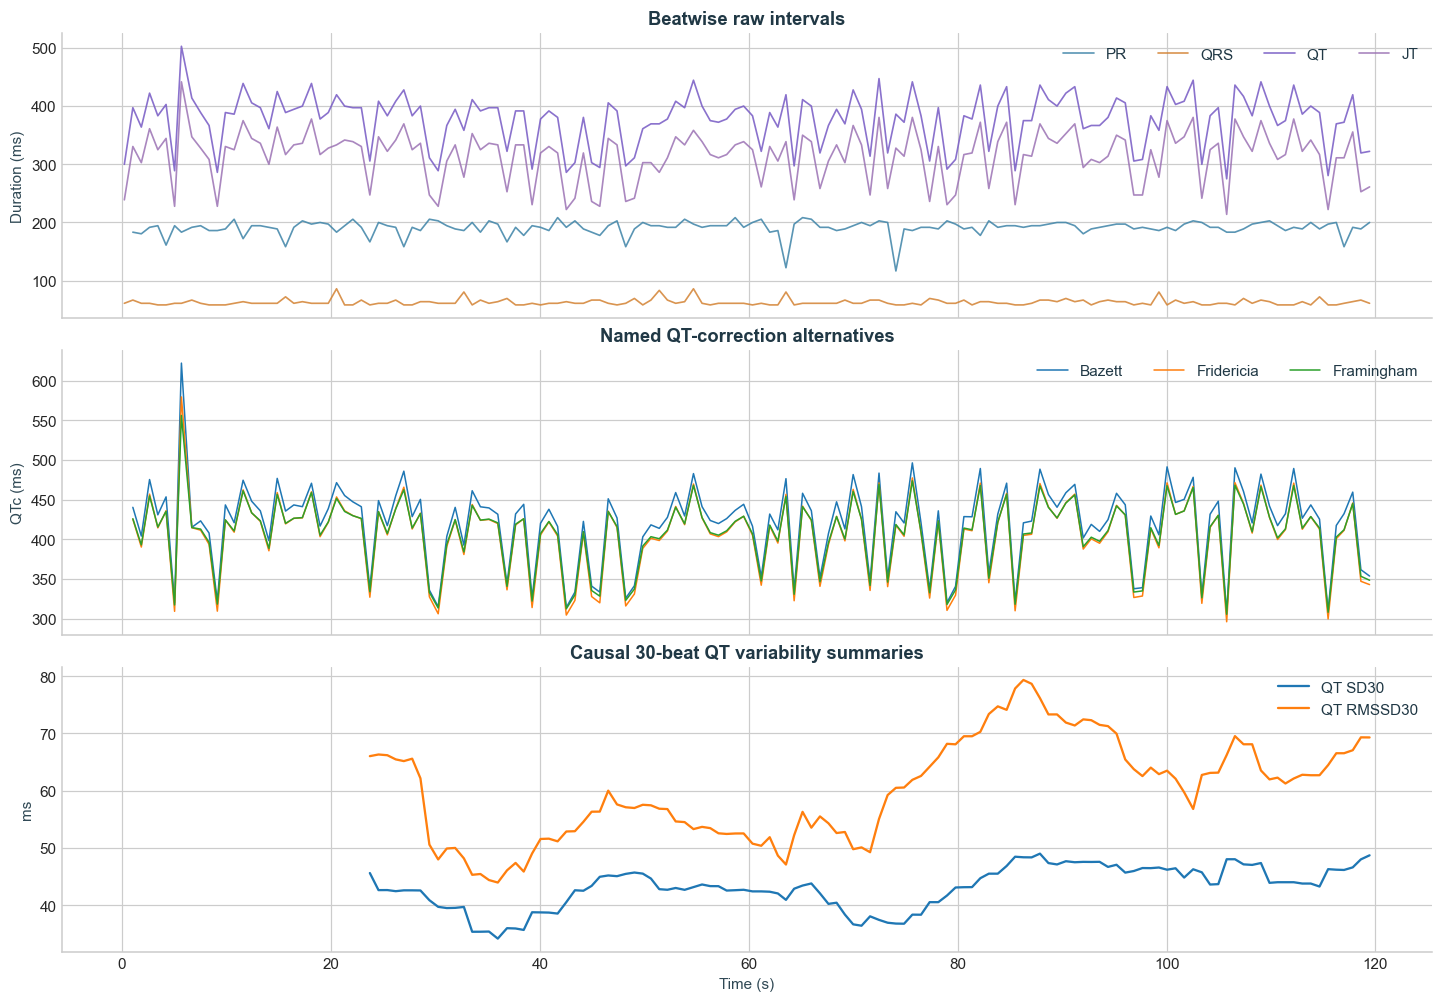

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
for column, label, color in [
    ("pr_interval_ms", "PR", "#3d83a7"),
    ("qrs_duration_ms", "QRS", "#d38232"),
    ("qt_interval_ms", "QT", "#7659c4"),
    ("jt_interval_ms", "JT", "#9b72b4"),
]:
    axes[0].plot(beats["r_peak_time_s"], beats[column], label=label, lw=1.1, alpha=.85, color=color)
axes[0].set(title="Beatwise raw intervals", ylabel="Duration (ms)")
axes[0].legend(ncol=4)
axes[1].plot(beats["r_peak_time_s"], beats["qtc_bazett_ms"], label="Bazett", lw=1)
axes[1].plot(beats["r_peak_time_s"], beats["qtc_fridericia_ms"], label="Fridericia", lw=1)
axes[1].plot(beats["r_peak_time_s"], beats["qtc_framingham_ms"], label="Framingham", lw=1)
axes[1].set(title="Named QT-correction alternatives", ylabel="QTc (ms)")
axes[1].legend(ncol=3)
defined = rolling30["qt_interval_variability30_defined"]
axes[2].plot(rolling30.loc[defined, "r_peak_time_s"], rolling30.loc[defined, "qt_interval_sd30_ms"], label="QT SD30")
axes[2].plot(rolling30.loc[defined, "r_peak_time_s"], rolling30.loc[defined, "qt_interval_rmssd30_ms"], label="QT RMSSD30")
axes[2].set(title="Causal 30-beat QT variability summaries", xlabel="Time (s)", ylabel="ms")
axes[2].legend()
plt.show()

## 5. Run the information-only five-beat and nine-beat views

The v2 branch reuses the frozen beat equations, then returns long-format
trailing five-beat descriptive summaries and a separate nine-beat QT
context. These values are deliberately marked `final_feature_matrix_eligible=False`
until interval validation and target-population testing are complete.

#### Code walkthrough — build five-beat descriptive and nine-beat QT context tables

        **Why this cell exists.** The literature supports raw PQRST timing dynamics and nine-beat QT context, but not an invented five-beat seizure score.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Information extractor | Requests trailing five-beat windows with at least four valid beats and no external eligibility column. | The demo shows mechanics while recording that no artifact gate was applied. |
| 2 | Summary | Reports beat, window, measurement, and availability counts. | The long-table scale is transparent. |
| 3 | Five-beat preview | Shows one row per measurement per endpoint with robust/descriptive statistics. | Different intervals are not forced into one scalar. |
| 4 | Nine-beat preview | Shows paired mean QT/RR and named corrections for complete nine-beat contexts. | This preserves the Brotherstone-style context separately. |

        **Evidence that the cell ran correctly**

        - Nonempty long-format five-beat rows and complete nine-beat QT rows appear.
- Metadata/columns retain information-only and non-integration status.

        **If that evidence is absent, investigate**

        - Insufficient valid beats or an unintended eligibility filter.
- Calling five-beat variability a published Diab feature—the paper used ordered raw peak dynamics.
- Calling nine-beat QT context a reproduced seizure detector.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [8]:
from ecg_cascade.conduction_information import extract_conduction_information

information = extract_conduction_information(
    pqrst, fs,
    window_beats=5,
    minimum_valid_beats=4,
    eligibility_column=None,
    landmark_method=prominence.parameters["method"],
)
display(pd.Series(information.summary(), name="conduction information v2 summary"))
display(information.information_windows.head(12))
display(information.qt_nine_beat_context.dropna(how="all", axis=1).tail(5))

branch_name                                     conduction_repolarization_information
schema_version                                              conduction_information_v2
beat_count                                                                        148
window_endpoint_count                                                             148
long_summary_row_count                                                           1480
complete_window_count                                                             144
parameters                          {'branch_name': 'conduction_repolarization_inf...
diagnostics                         {'measurement_gate': 'information_only_not_pip...
information_only                                                                 True
final_feature_matrix_eligible                                                   False
seizure_probability_produced                                                    False
clinical_interpretation_produced                      

,beat_index,r_peak_time_s,patient_id,lead_name,window_start_beat_index,history_beats5,history5_complete,eligible_beats5,eligible_fraction5,elapsed_time5_s,previous_nonoverlapping_window5_available,information_only,final_feature_matrix_eligible,seizure_probability_produced,clinical_interpretation_produced,abnormality_label_produced,measurement,source_beat_column,unit,valid_beats,availability_fraction,summary_defined,summary_status,support_end_sample,mean_ms,median_ms,sample_sd_ms,mad_ms,iqr_ms,minimum_ms,maximum_ms,range_ms,rmssd_ms,median_abs_successive_difference_ms,max_abs_successive_difference_ms,theil_sen_slope_ms_per_beat,late2_minus_early2_median_ms,current_minus_prior_median_ms,previous_window_comparison_defined,median_shift_vs_previous_window_ms,absolute_median_shift_vs_previous_window_ms,robust_shift_scale_ms,normalized_shift_vs_previous_window
0,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,p_duration,p_duration_ms,ms,0,0.0,False,insufficient_history,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,pr_interval,pr_interval_ms,ms,0,0.0,False,insufficient_history,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
2,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,pr_segment,pr_segment_ms,ms,1,0.2,False,insufficient_history,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,qrs_duration,qrs_duration_ms,ms,1,0.2,False,insufficient_history,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,qt_interval,qt_interval_ms,ms,1,0.2,False,insufficient_history,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
5,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,jt_interval,jt_interval_ms,ms,1,0.2,False,insufficient_history,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
6,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,t_peak_to_end,t_peak_to_end_ms,ms,1,0.2,False,insufficient_history,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
7,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,qtc_bazett,qtc_bazett_ms,ms,0,0.0,False,insufficient_history,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
8,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,qtc_fridericia,qtc_fridericia_ms,ms,0,0.0,False,insufficient_history,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
9,0,0.213889,mitdb_100,MLII,0,1,False,1,0.2,0.000000,False,True,False,False,False,False,qtc_framingham,qtc_framingham_ms,ms,0,0.0,False,insufficient_history,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


,beat_index,r_peak_time_s,patient_id,lead_name,qt_rr_mean9_defined,qt_interval_mean9_ms,preceding_rr_mean9_ms,qtc_bazett_from_means9_ms,qtc_fridericia_from_means9_ms,qtc_framingham_from_means9_ms,information_only,final_feature_matrix_eligible,seizure_probability_produced,clinical_interpretation_produced,abnormality_label_produced
143,143,116.247222,mitdb_100,MLII,True,378.086420,801.543210,422.306347,407.019702,408.648765,True,False,False,False,False
144,144,116.988889,mitdb_100,MLII,True,375.000000,792.901235,421.135372,405.158452,406.893210,True,False,False,False,False
145,145,117.822222,mitdb_100,MLII,True,380.864198,799.691358,425.901283,410.326295,411.711728,True,False,False,False,False
146,146,118.602778,mitdb_100,MLII,True,374.691358,802.777778,418.192274,403.157951,405.063580,True,False,False,False,False
147,147,119.433333,mitdb_100,MLII,True,362.037037,806.790123,403.062798,388.895404,391.791358,True,False,False,False,False


## 6. Case study — record 231 separates atrial activity from ventricular RR

The prior [record-231 conduction case report](../../reports/MITBIH_Record_231_Conduction_False_Detection_Case_Analysis.pdf)
documents 2:1/Mobitz-II conduction context. Smaller deflections occurred
between large annotated QRS complexes. Their identity as non-conducted
atrial activity is physiologically plausible, but the MIT–BIH beat file
does not directly label every atrial deflection, so the report correctly
preserves that statement as an inference.

This is precisely why a conduction branch exists. An intervening atrial
wave may be real physiology yet must not become a ventricular timestamp
and create false short RR intervals. The cell below reruns the current
NeuroKit–Zhai branch on the report's 461.8–470.3 s strip and shows which
events align with expert ventricular beats.

Paper evidence constraining this branch:

- Diab et al. (2025) retained ordered raw P/Q/S/T timing dynamics rather
  than inventing five-beat interval averages, [DOI 10.1016/j.neucli.2025.103098](https://doi.org/10.1016/j.neucli.2025.103098).
- Brotherstone et al. (2010) used nine consecutive QT/RR pairs and named
  QT corrections, [DOI 10.1111/j.1528-1167.2009.02281.x](https://doi.org/10.1111/j.1528-1167.2009.02281.x).
- The EHRA/ESC position statement warns that QT variability is easily
  contaminated by T-end error and morphology instability,
  [DOI 10.1093/europace/euv405](https://doi.org/10.1093/europace/euv405).

#### Code walkthrough — reproduce record 231's conduction-related false-detection strip

        **Why this cell exists.** The prior report showed that smaller physiological atrial deflections can be mistaken for ventricular beats; agreement/disagreement must not be collapsed into generic artifact.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Case scope | Loads record 231 MLII from 461.8–470.3 s. | This is the same explanatory strip documented in the prior case report. |
| 2 | Detector rerun | Runs NeuroKit and Zhai on the current local signal. | The screenshot is produced by current branch code. |
| 3 | Expert beats | Loads and time-filters `.atr` ventricular beat annotations. | Annotated QRS events anchor the interpretation. |
| 4 | Count assertions | Requires five expert beats, a matching-size Zhai lane, and extra NeuroKit events. | The known regression pattern fails visibly if behavior changes. |
| 5 | Annotated plot | Overlays expert, NeuroKit, and Zhai markers on the ECG. | Smaller intervening deflections and the detector responses are directly visible. |

        **Evidence that the cell ran correctly**

        - Five expert and five Zhai events align with large QRS complexes, while NeuroKit also marks smaller intervening deflections.
- The printed case counts and assertions pass.

        **If that evidence is absent, investigate**

        - Calling every intervening deflection definitively a P wave—the report says that identity is physiologically plausible but not directly annotated.
- Using the case to declare Zhai universally superior.
- Allowing an extra ventricular timestamp to create false short RR intervals.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

,count
expert_ventricular_beats,5
NeuroKit_events,11
Zhai_events,5


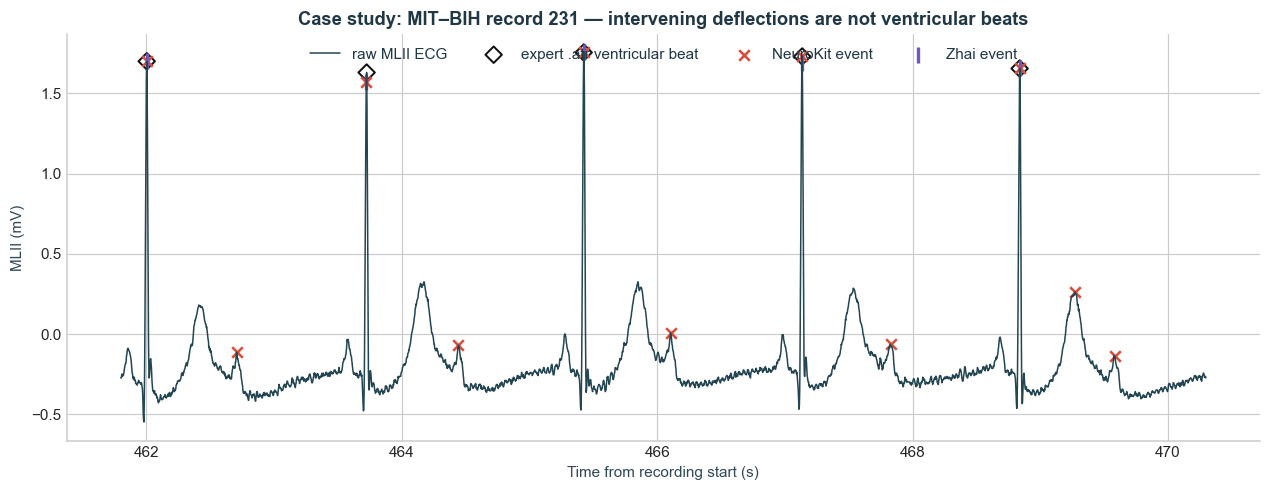

PASS — record 231 reproduces the conduction-related extra-event pattern.


In [9]:
from ecg_cascade.wfdb_io import load_wfdb_beat_annotations

CASE_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "231"
)
case_segment = load_wfdb_segment(
    CASE_RECORD, channel="MLII", start_s=461.8, duration_s=8.5
)
case_cascade = run_neurokit_zhai_array(
    case_segment.samples,
    case_segment.sampling_rate_hz,
    segment_start_s=case_segment.start_s,
    config=NeuroKitZhaiConfig(compute_inverted_context=False),
    source_metadata={"record": "231", "case": "intervening deflections"},
)

case_reference_samples, case_reference_symbols = load_wfdb_beat_annotations(CASE_RECORD)
case_reference_times_all = case_reference_samples / case_segment.sampling_rate_hz
case_reference_keep = (
    (case_reference_times_all >= case_segment.start_s)
    & (case_reference_times_all < case_segment.start_s + case_segment.duration_s)
)
case_reference_times = case_reference_times_all[case_reference_keep]
case_reference_symbols = np.asarray(case_reference_symbols)[case_reference_keep]
case_nk_times = (
    case_segment.start_s
    + case_cascade.selected.neurokit.detector.peak_samples / case_segment.sampling_rate_hz
)
case_zhai_times = (
    case_segment.start_s
    + case_cascade.selected.zhai.detector.peak_samples / case_segment.sampling_rate_hz
)
case_counts = pd.Series({
    "expert_ventricular_beats": case_reference_times.size,
    "NeuroKit_events": case_nk_times.size,
    "Zhai_events": case_zhai_times.size,
}, name="count")
display(case_counts.to_frame())

assert case_reference_times.size == 5
assert case_nk_times.size >= case_reference_times.size + 4
assert abs(case_zhai_times.size - case_reference_times.size) <= 1

case_time = case_segment.start_s + np.arange(case_segment.samples.size) / case_segment.sampling_rate_hz
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(case_time, case_segment.samples, color="#244652", lw=1.0, label="raw MLII ECG")
ax.scatter(
    case_reference_times,
    np.interp(case_reference_times, case_time, case_segment.samples),
    marker="D", facecolors="none", edgecolors="#111111", s=58, linewidths=1.3,
    label="expert .atr ventricular beat",
)
ax.scatter(
    case_nk_times,
    np.interp(case_nk_times, case_time, case_segment.samples),
    marker="x", color="#d94f3d", s=48, linewidths=1.7,
    label="NeuroKit event",
)
ax.scatter(
    case_zhai_times,
    np.interp(case_zhai_times, case_time, case_segment.samples),
    marker="|", color="#7057b8", s=120, linewidths=2.2,
    label="Zhai event",
)
ax.set(
    title="Case study: MIT–BIH record 231 — intervening deflections are not ventricular beats",
    xlabel="Time from recording start (s)", ylabel="MLII (mV)",
)
ax.legend(ncol=4, loc="upper center")
plt.show()
print("PASS — record 231 reproduces the conduction-related extra-event pattern.")

### How to read the successful-run screenshot

1. Hollow black diamonds mark the five expert ventricular beats on the
   large QRS complexes.
2. Purple Zhai markers should align with those large complexes in this
   strip. Red NeuroKit crosses also appear on smaller intervening
   deflections, producing more events than expert ventricular beats.
3. The screenshot supports the narrow statement that this detector can
   confuse intervening physiology with ventricular events here. It does
   not prove the exact atrial-wave identity, declare artifact, diagnose
   heart block, or establish universal detector superiority.
4. The conduction extractor must therefore consume a validated
   ventricular anchor lane and retain P/QRS/T landmark availability.

## 7. Export every conduction table and its audit metadata

#### Code walkthrough — export all conduction granularities and audit metadata

        **Why this cell exists.** Beatwise, 30-beat, five-beat-long, and nine-beat tables have different meanings and must remain distinguishable.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Table map | Names PQRST, beat, rolling30, information-window, and QT9 outputs. | Every processing stage remains independently inspectable. |
| 2 | CSV loop | Writes each table without an extra index. | Schemas can be consumed by later ablations. |
| 3 | Metadata bundle | Collects delineation, timing, information parameters, and diagnostics. | Boundary method and availability rules travel with values. |
| 4 | Shape table | Displays rows and columns for all exports. | Empty or unexpectedly narrow tables are obvious. |

        **Evidence that the cell ran correctly**

        - Five CSV files plus `conduction_metadata.json` exist and every shape row is nonzero.

        **If that evidence is absent, investigate**

        - Joining different granularities without explicit keys.
- Dropping landmark provenance.
- Promoting information-only columns into a final matrix before validation.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [10]:
tables = {
    "prominence_pqrst_features.csv": pqrst,
    "conduction_beat_features.csv": beats,
    "conduction_rolling30_features.csv": rolling30,
    "conduction_information_windows_long.csv": information.information_windows,
    "conduction_qt_nine_beat_context.csv": information.qt_nine_beat_context,
}
for filename, frame in tables.items():
    frame.to_csv(OUTPUT_DIR / filename, index=False)
metadata = {
    "delineation": prominence.parameters,
    "timing": timing.parameters,
    "timing_diagnostics": timing.diagnostics,
    "information": information.parameters,
    "information_diagnostics": information.diagnostics,
}
(OUTPUT_DIR / "conduction_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
display(pd.DataFrame({name: {"rows": len(frame), "columns": len(frame.columns)} for name, frame in tables.items()}).T)

,rows,columns
prominence_pqrst_features.csv,148,39
conduction_beat_features.csv,148,40
conduction_rolling30_features.csv,148,46
conduction_information_windows_long.csv,1480,43
conduction_qt_nine_beat_context.csv,148,15


## 8. Notebook-level acceptance checks and limits

#### Code walkthrough — enforce conduction row alignment, availability, and non-clinical scope

        **Why this cell exists.** Interval arithmetic must stay aligned with anchors, and exploratory information must remain excluded from the final matrix until its measurement gate passes.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Row alignment | Requires equal anchor, PQRST, and beat-table lengths. | Every interval row must refer to exactly one R anchor. |
| 2 | Availability | Requires QRS, QT, rolling30 QT, and complete five-beat histories. | All requested paths executed on the demo. |
| 3 | No clinical outputs | Rejects seizure probabilities, clinical interpretations, abnormality labels, and final-matrix eligibility. | The branch is measurement-only. |

        **Evidence that the cell ran correctly**

        - The cell ends with `PASS — conduction timing and information branches executed with all safety assertions intact.`

        **If that evidence is absent, investigate**

        - The first failed row-count or availability check.
- Upstream P/T delineation quality.
- Any attempt to bypass the frozen non-integration flags.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [11]:
assert len(beats) == len(pqrst) == len(track.detector.peak_samples)
assert beats["qrs_duration_defined"].any()
assert beats["qt_interval_defined"].any()
assert rolling30["qt_interval_variability30_defined"].any()
assert information.information_windows[f"history{information.parameters['window_beats']}_complete"].any()
assert not beats["seizure_probability_produced"].any()
assert not beats["clinical_interpretation_produced"].any()
assert not information.beat_measurements["final_feature_matrix_eligible"].any()
assert not information.beat_measurements["abnormality_label_produced"].any()
print("PASS — conduction timing and information branches executed with all safety assertions intact.")

PASS — conduction timing and information branches executed with all safety assertions intact.


### Interpretation limits

- P-onset and T-offset error tails can be as large as, or larger than,
  the physiological variability being measured.
- QT correction changes rate dependence; it does not create a diagnosis.
- Thirty-beat QTVI/STV summaries are exploratory and are not equivalent to
  studies using longer stationary recordings.
- Five-beat descriptive changes can reflect rate, ectopy, physiology,
  artifact, lead movement, or landmark error. No cause is assigned.
- External signal-quality eligibility can be supplied later, but this
  branch never invents or reinterprets an artifact score.

## Exact implementation appendix

To make the executed notebook a durable audit artifact, this section
embeds the **complete source text** of the modules used above and records
a SHA-256 digest for each file. The algorithms are imported from these
tested modules; they are not rewritten in a second, drifting notebook copy.

#### Code walkthrough — embed exact implementation source and cryptographic hashes

        **Why this cell exists.** A notebook can otherwise become an attractive but stale copy of production code; this cell records precisely what implementation was executed.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Source list | Freezes the branch modules and scripts included in the appendix. | The reader can audit the implementation boundary. |
| 2 | File loop | Reads every file as UTF-8, counts lines, and calculates SHA-256. | A one-character source change produces a different digest. |
| 3 | Rendered source | Displays the complete Python text in the executed notebook. | Every internal line remains reviewable without opening a second application. |
| 4 | Manifest export | Writes `source_manifest.json` and displays its table. | Automated checks can compare filenames, line counts, and hashes later. |

        **Evidence that the cell ran correctly**

        - Each expected module appears as a rendered code block with a 64-character SHA-256 digest.
- The final table contains one row per requested source file and positive line counts.
- `source_manifest.json` is saved in the branch output directory.

        **If that evidence is absent, investigate**

        - A source module that moved or is missing.
- An unexpected project root, which would hash the wrong files.
- Notebook size limits if a front end refuses to render the complete appendix.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [12]:
SOURCE_FILES = ['src/ecg_cascade/prominence_morphology.py', 'src/ecg_cascade/conduction_timing.py', 'src/ecg_cascade/conduction_information.py', 'src/ecg_cascade/delineation_validation.py', 'scripts/run_conduction_timing.py', 'scripts/run_conduction_information.py']
source_manifest = []
for relative in SOURCE_FILES:
    path = PROJECT / relative
    text = path.read_text(encoding="utf-8")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()
    source_manifest.append({"file": relative, "sha256": digest, "lines": len(text.splitlines())})
    display(Markdown(f"### `{relative}`  \nSHA-256: `{digest}` · {len(text.splitlines())} lines"))
    display(Code(text, language="python"))

source_manifest_path = OUTPUT_DIR / "source_manifest.json"
source_manifest_path.write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
display(pd.DataFrame(source_manifest))
print("Saved:", source_manifest_path)

### `src/ecg_cascade/prominence_morphology.py`  
SHA-256: `13c614a1e2b7ea788647f66da9b8b279db09b638f8642fc96c2280044099baeb` · 378 lines

"""Interpretable P-QRS-T features from deterministic prominence delineation."""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Mapping

import neurokit2 as nk
import numpy as np
import pandas as pd

from .delineation_validation import LANDMARK_NAMES, associate_landmarks_with_anchors
from .peaks import orient_signal


_NEUROKIT_KEYS = {
    "p_onset": "ECG_P_Onsets",
    "p_peak": "ECG_P_Peaks",
    "p_offset": "ECG_P_Offsets",
    "qrs_onset": "ECG_R_Onsets",
    "qrs_offset": "ECG_R_Offsets",
    "t_onset": "ECG_T_Onsets",
    "t_peak": "ECG_T_Peaks",
    "t_offset": "ECG_T_Offsets",
}

_OPTIONAL_PEAK_KEYS = {
    "q_peak": "ECG_Q_Peaks",
    "s_peak": "ECG_S_Peaks",
}


@dataclass(frozen=True)
class ProminenceMorphologyResult:
    """Per-beat landmarks and manually interpretable morphology features."""

    anchor_track: str
    landmarks: Mapping[str, np.ndarray]
    features: pd.DataFrame
    parameters: dict[str, Any]

    def summary(self) -> dict[str, object]:
        return {
            "anchor_track": self.anchor_track,
            "beat_count": int(self.features.shape[0]),
            "complete_qrs_count": int(self.features["complete_qrs"].sum()),
            "complete_qs_peak_count": int(self.features["complete_qs_peaks"].sum()),
            "q_s_peak_order_pass_count": int(
                self.features["q_s_peak_order_valid"].sum()
            ),
            "complete_pqrst_count": int(self.features["complete_pqrst"].sum()),
            "physiological_order_pass_count": int(
                self.features["physiological_order_valid"].sum()
            ),
            "parameters": self.parameters,
            "seizure_probability_produced": False,
            "artifact_label_produced": False,
        }


def extract_prominence_morphology(
    ecg: np.ndarray,
    anchor_peak_samples: np.ndarray,
    sampling_rate_hz: float,
    *,
    anchor_track: str,
    patient_id: str,
    lead_name: str,
    segment_start_s: float = 0.0,
    orientation: str = "original",
    cleaning_method: str = "neurokit",
) -> ProminenceMorphologyResult:
    """Run NeuroKit's Emrich-2024 prominence delineator and extract features."""

    signal = _validate_inputs(ecg, anchor_peak_samples, sampling_rate_hz)
    if not str(patient_id).strip() or not str(lead_name).strip():
        raise ValueError("patient_id and lead_name must be non-empty")
    oriented = orient_signal(signal, orientation)
    peaks = np.unique(np.asarray(anchor_peak_samples, dtype=np.int64))
    cleaned = np.asarray(
        nk.ecg_clean(
            oriented,
            sampling_rate=sampling_rate_hz,
            method=cleaning_method,
        ),
        dtype=np.float64,
    )
    _, waves = nk.ecg_delineate(
        cleaned,
        rpeaks=peaks,
        sampling_rate=sampling_rate_hz,
        method="prominence",
        check=False,
    )
    landmarks = _align_neurokit_landmarks(waves, peaks, sampling_rate_hz, signal.size)
    features = build_pqrst_feature_table(
        oriented,
        peaks,
        landmarks,
        sampling_rate_hz,
        anchor_track=anchor_track,
        patient_id=patient_id,
        lead_name=lead_name,
        segment_start_s=segment_start_s,
    )
    parameters: dict[str, Any] = {
        "method": "emrich2024_prominence_via_neurokit2_0_2_13",
        "reference": (
            "Emrich et al. 2024, Physiology-informed ECG delineation based "
            "on peak prominence"
        ),
        "reference_url": (
            "https://eurasip.org/Proceedings/Eusipco/Eusipco2024/"
            "pdfs/0001402.pdf"
        ),
        "patient_id": str(patient_id),
        "lead_name": str(lead_name),
        "anchor_track": anchor_track,
        "r_peaks_are_inputs": True,
        "cleaning_method": cleaning_method,
        "polarity_handling": "preserved_no_silent_inversion",
        "missing_landmarks_retained": True,
        "q_s_peaks_retained_for_paper_aligned_peak_dynamics": True,
 

### `src/ecg_cascade/conduction_timing.py`  
SHA-256: `92dca515e1d4d4b543146fde9ba6647752aba216ad07c38b82dee2f5b2cfed03` · 509 lines

"""Auditable conduction and repolarization timing measurements.

This branch consumes already aligned P/QRS/T landmarks.  It does not detect
beats, delineate waves, diagnose conduction disease, or classify seizures.
Trailing summaries use only the current and earlier beats; the causality of the
upstream landmark generator remains a separate validation responsibility.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd


_SAMPLE_COLUMNS = {
    "p_onset": "p_onset_sample_in_segment",
    "p_offset": "p_offset_sample_in_segment",
    "qrs_onset": "qrs_onset_sample_in_segment",
    "r_peak": "r_peak_sample_in_segment",
    "qrs_offset": "qrs_offset_sample_in_segment",
    "t_peak": "t_peak_sample_in_segment",
    "t_offset": "t_offset_sample_in_segment",
}

_ROLLING_INTERVALS = (
    "pr_interval_ms",
    "qrs_duration_ms",
    "qt_interval_ms",
    "jt_interval_ms",
)


@dataclass(frozen=True)
class ConductionTimingResult:
    """Beatwise intervals plus causal trailing timing summaries."""

    beat_features: pd.DataFrame
    rolling_features: pd.DataFrame
    parameters: dict[str, Any]
    diagnostics: dict[str, Any]

    def summary(self) -> dict[str, object]:
        return {
            "branch_name": "conduction",
            "beat_count": int(self.beat_features.shape[0]),
            "rolling_row_count": int(self.rolling_features.shape[0]),
            "pr_defined_count": int(self.beat_features["pr_interval_defined"].sum()),
            "qrs_defined_count": int(self.beat_features["qrs_duration_defined"].sum()),
            "qt_defined_count": int(self.beat_features["qt_interval_defined"].sum()),
            "parameters": self.parameters,
            "diagnostics": self.diagnostics,
            "seizure_probability_produced": False,
            "clinical_interpretation_produced": False,
        }


def qt_correct_bazett(qt_ms: np.ndarray, rr_ms: np.ndarray) -> np.ndarray:
    """Return Bazett QTc in ms: ``QT / sqrt(RR_s)``."""

    qt, rr = _validate_qt_rr(qt_ms, rr_ms)
    output = np.full(qt.size, np.nan, dtype=np.float64)
    valid = np.isfinite(qt) & np.isfinite(rr)
    output[valid] = qt[valid] / np.sqrt(rr[valid] / 1000.0)
    return output


def qt_correct_fridericia(qt_ms: np.ndarray, rr_ms: np.ndarray) -> np.ndarray:
    """Return Fridericia QTc in ms: ``QT / cbrt(RR_s)``."""

    qt, rr = _validate_qt_rr(qt_ms, rr_ms)
    output = np.full(qt.size, np.nan, dtype=np.float64)
    valid = np.isfinite(qt) & np.isfinite(rr)
    output[valid] = qt[valid] / np.cbrt(rr[valid] / 1000.0)
    return output


def qt_correct_framingham(qt_ms: np.ndarray, rr_ms: np.ndarray) -> np.ndarray:
    """Return Framingham QTc in ms: ``QT_s + 0.154 * (1 - RR_s)``."""

    qt, rr = _validate_qt_rr(qt_ms, rr_ms)
    output = np.full(qt.size, np.nan, dtype=np.float64)
    valid = np.isfinite(qt) & np.isfinite(rr)
    output[valid] = qt[valid] + 154.0 * (1.0 - rr[valid] / 1000.0)
    return output


def qt_variability_index_rr(qt_ms: np.ndarray, rr_ms: np.ndarray) -> float:
    """Return the common RR-denominator QTVI adaptation.

    This is ``log10[(var(QT)/mean(QT)^2) / (var(RR)/mean(RR)^2)]``.
    It is intentionally named ``_rr`` because Berger's original 1997 QTVI used
    heart-rate variance; both variants are exported by this module.
    """

    qt, rr = _joint_finite_positive(qt_ms, rr_ms)
    if qt.size < 2:
        return np.nan
    return _normalized_variance_log_ratio(qt, rr)


def qt_variability_index_hr(qt_ms: np.ndarray, rr_ms: np.ndarray) -> float:
    """Return Berger-style QTVI using heart-rate variance in the denominator."""

    qt, rr = _joint_finite_positive(qt_ms, rr_ms)
    if qt.size < 2:
        return np.nan
    heart_rate_bpm = 60000.0 / rr
    return _normalized_variance_log_ratio(qt, heart_rate_bpm)


def short_term_variability_30(interval_ms: np.ndarray) -> float:
    """Return published 30-beat short-term variability in ms.


### `src/ecg_cascade/conduction_information.py`  
SHA-256: `b9bc8cdea894b47c97156ac47f28b75e0f6093219027d02ac7bc247605d3b932` · 738 lines

...

"""Run the standalone conduction timing prototype on one WFDB lead."""

from __future__ import annotations

import argparse
import json
from pathlib import Path
import sys

PROJECT = Path(__file__).resolve().parents[1]
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ecg_cascade.conduction_timing import extract_conduction_timing  # noqa: E402
from ecg_cascade.prominence_morphology import extract_prominence_morphology  # noqa: E402
from ecg_cascade.wfdb_io import (  # noqa: E402
    load_wfdb_beat_annotations,
    load_wfdb_segment,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--record",
        type=Path,
        required=True,
        help="WFDB record path without .hea/.dat suffixes.",
    )
    parser.add_argument("--channel", default="0")
    parser.add_argument("--annotation-extension", default="atr")
    parser.add_argument("--start-s", type=float, default=0.0)
    parser.add_argument("--duration-s", type=float, default=None)
    parser.add_argument("--patient-id", required=True)
    parser.add_argument("--lead-name", default=None)
    parser.add_argument("--variability-window-beats", type=int, default=30)
    parser.add_argument("--minimum-valid-fraction", type=float, default=0.8)
    parser.add_argument("--output", type=Path, required=True)
    return parser.parse_args()


def main() -> int:
    args = parse_args()
    channel: int | str = (
        int(args.channel) if str(args.channel).isdigit() else str(args.channel)
    )
    segment = load_wfdb_segment(
        args.record,
        channel=channel,
        start_s=args.start_s,
        duration_s=args.duration_s,
    )
    end_sample = segment.start_sample + segment.samples.size
    peaks, symbols = load_wfdb_beat_annotations(
        args.record,
        extension=args.annotation_extension,
        start_sample=segment.start_sample,
        end_sample=end_sample,
    )
    lead_name = args.lead_name or segment.channel_name
    prominence = extract_prominence_morphology(
        segment.samples,
        peaks,
        segment.sampling_rate_hz,
        anchor_track=f"expert_{args.annotation_extension}",
        patient_id=args.patient_id,
        lead_name=lead_name,
        segment_start_s=segment.start_s,
    )
    conduction = extract_conduction_timing(
        prominence.features,
        segment.sampling_rate_hz,
        variability_window_beats=args.variability_window_beats,
        minimum_valid_fraction=args.minimum_valid_fraction,
        landmark_method=str(prominence.parameters["method"]),
    )

    symbol_by_sample = {
        int(sample): str(symbol) for sample, symbol in zip(peaks, symbols)
    }
    beat_features = conduction.beat_features.copy()
    beat_features["reference_symbol"] = beat_features[
        "r_peak_sample_in_segment"
    ].map(symbol_by_sample)

    output = args.output.expanduser().resolve()
    output.mkdir(parents=True, exist_ok=True)
    prominence.features.to_csv(output / "pqrst_landmarks_and_morphology.csv", index=False)
    beat_features.to_csv(output / "conduction_beat_features.csv", index=False)
    conduction.rolling_features.to_csv(
        output / "conduction_rolling_features.csv", index=False
    )
    scope = {
        "record": str(Path(args.record).expanduser().resolve()),
        "channel_index": segment.channel_index,
        "lead_name": lead_name,
        "sampling_rate_hz": segment.sampling_rate_hz,
        "start_s": segment.start_s,
        "duration_s": segment.duration_s,
        "annotation_extension": args.annotation_extension,
        "reference_r_anchor_count": int(peaks.size),
        "reference_symbols_are_context_not_training_targets": True,
        "pqrst_summary": prominence.summary(),
        "conduction_summary": conduction.summary(),
    }
    (output / "run_scope.json").write_text(
        json.dumps(scope, indent=2), encoding="utf-8"
    )
    print(json.dumps(conduction.summary(),

### `scripts/run_conduction_information.py`  
SHA-256: `b4b4d65cf40540f99515c75f84b30b6bd9abc85e0c487a762d90579fe1f34e68` · 125 lines

"""Run the standalone conduction/repolarization information branch."""

from __future__ import annotations

import argparse
import json
from pathlib import Path
import sys

PROJECT = Path(__file__).resolve().parents[1]
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ecg_cascade.conduction_information import (  # noqa: E402
    extract_conduction_information,
)
from ecg_cascade.prominence_morphology import extract_prominence_morphology  # noqa: E402
from ecg_cascade.wfdb_io import (  # noqa: E402
    load_wfdb_beat_annotations,
    load_wfdb_segment,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--record",
        type=Path,
        required=True,
        help="WFDB record path without .hea/.dat suffixes.",
    )
    parser.add_argument("--channel", default="0")
    parser.add_argument("--annotation-extension", default="atr")
    parser.add_argument("--start-s", type=float, default=0.0)
    parser.add_argument("--duration-s", type=float, default=None)
    parser.add_argument("--patient-id", required=True)
    parser.add_argument("--lead-name", default=None)
    parser.add_argument("--window-beats", type=int, default=5)
    parser.add_argument("--minimum-valid-beats", type=int, default=4)
    parser.add_argument("--output", type=Path, required=True)
    return parser.parse_args()


def main() -> int:
    args = parse_args()
    channel: int | str = (
        int(args.channel) if str(args.channel).isdigit() else str(args.channel)
    )
    segment = load_wfdb_segment(
        args.record,
        channel=channel,
        start_s=args.start_s,
        duration_s=args.duration_s,
    )
    end_sample = segment.start_sample + segment.samples.size
    peaks, symbols = load_wfdb_beat_annotations(
        args.record,
        extension=args.annotation_extension,
        start_sample=segment.start_sample,
        end_sample=end_sample,
    )
    lead_name = args.lead_name or segment.channel_name
    prominence = extract_prominence_morphology(
        segment.samples,
        peaks,
        segment.sampling_rate_hz,
        anchor_track=f"expert_{args.annotation_extension}",
        patient_id=args.patient_id,
        lead_name=lead_name,
        segment_start_s=segment.start_s,
    )
    result = extract_conduction_information(
        prominence.features,
        segment.sampling_rate_hz,
        window_beats=args.window_beats,
        minimum_valid_beats=args.minimum_valid_beats,
        landmark_method=str(prominence.parameters["method"]),
    )

    symbol_by_sample = {
        int(sample): str(symbol) for sample, symbol in zip(peaks, symbols)
    }
    beat_measurements = result.beat_measurements.copy()
    beat_measurements["reference_symbol"] = beat_measurements[
        "r_peak_sample_in_segment"
    ].map(symbol_by_sample)

    output = args.output.expanduser().resolve()
    output.mkdir(parents=True, exist_ok=True)
    prominence.features.to_csv(output / "pqrst_landmarks.csv", index=False)
    beat_measurements.to_csv(
        output / "conduction_information_beats.csv", index=False
    )
    result.information_windows.to_csv(
        output / f"conduction_information_windows{args.window_beats}_long.csv",
        index=False,
    )
    result.qt_nine_beat_context.to_csv(
        output / "conduction_information_qt_context9.csv",
        index=False,
    )
    scope = {
        "record": str(Path(args.record).expanduser().resolve()),
        "channel_index": segment.channel_index,
        "lead_name": lead_name,
        "sampling_rate_hz": segment.sampling_rate_hz,
        "start_s": segment.start_s,
        "duration_s": segment.duration_s,
        "annotation_extension": args.annotation_extension,
        "reference_r_anchor_count": int(peaks.size),
        "reference_symbols_are_context_not_training_targets": True,
        "pqrst_summary": prominence.summary(),
        "information_summary": result.summary(),
    

,file,sha256,lines
0,src/ecg_cascade/prominence_morphology.py,13c614a1e2b7ea788647f66da9b8b279db09b638f8642f...,378
1,src/ecg_cascade/conduction_timing.py,92dca515e1d4d4b543146fde9ba6647752aba216ad07c3...,509
2,src/ecg_cascade/conduction_information.py,b9bc8cdea894b47c97156ac47f28b75e0f6093219027d0...,738
3,src/ecg_cascade/delineation_validation.py,02933b9885f5070e47d67e2789163b970642751296130e...,668
4,scripts/run_conduction_timing.py,ba2bca3690385d0362bd0d2c8395cea2716aa8eed3201d...,115
5,scripts/run_conduction_information.py,b4b4d65cf40540f99515c75f84b30b6bd9abc85e0c487a...,125


Saved: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\conduction\source_manifest.json
